# Wolfpack Trend — Performance Tear Sheet

Runs fully locally. No QC needed.

**Setup:** Run `simulate_backtest.py` first to generate the `output/` folder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import os

DATA_DIR      = './output'
RISK_FREE     = 0.0
STARTING_CASH = 100_000.0

assert os.path.exists(DATA_DIR), f'Run simulate_backtest.py first'
print('Config OK')

Config OK


In [3]:
snap = pd.read_csv(f'{DATA_DIR}/daily_snapshots.csv', parse_dates=['date'], index_col='date').sort_index()
spy  = pd.read_csv(f'{DATA_DIR}/spy_benchmark.csv',  parse_dates=['date'], index_col='date').sort_index()
print(f'Strategy : {len(snap)} days  {snap.index[0].date()} to {snap.index[-1].date()}')
snap.head(3)

Strategy : 523 days  2020-01-01 to 2021-12-31


,nav,cash,gross_exposure,net_exposure,long_exposure,short_exposure,daily_pnl,cumulative_pnl,daily_slippage,num_positions,estimated_vol
date,,,,,,,,,,,
2020-01-01,100000.00,100000.00,0.0000,0.0000,0.0000,0.0000,0.00,0.00,0.0,0,NaN
2020-01-02,99907.29,102749.09,0.0511,-0.0284,0.0113,0.0398,-92.71,-92.71,0.0,17,NaN
2020-01-03,99892.23,98632.21,0.1035,0.0126,0.0581,0.0455,-15.07,-107.77,0.0,24,NaN


In [4]:
sr = snap['nav'].pct_change().dropna()
br = spy['price'].pct_change().dropna()
common = sr.index.intersection(br.index)
sr, br = sr.loc[common], br.loc[common]

def metrics(returns, label, rf=RISK_FREE):
    ann    = 252
    total  = (1 + returns).prod() - 1
    annual = (1 + total) ** (ann / len(returns)) - 1
    vol    = returns.std() * np.sqrt(ann)
    sharpe = (annual - rf) / vol if vol > 0 else np.nan
    cum    = (1 + returns).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar = annual / abs(max_dd) if max_dd != 0 else np.nan
    win    = (returns > 0).mean()
    print(f'\n── {label} ──')
    for k,v in [('Total Return', f'{total*100:+.2f}%'), ('Ann. Return', f'{annual*100:+.2f}%'),
                ('Ann. Vol', f'{vol*100:.2f}%'), ('Sharpe', f'{sharpe:.3f}'),
                ('Max DD', f'{max_dd*100:.2f}%'), ('Calmar', f'{calmar:.3f}'),
                ('Win Rate', f'{win*100:.1f}%')]:
        print(f'  {k:<18}: {v}')
    return dict(label=label, total=total, annual=annual, vol=vol,
                sharpe=sharpe, max_dd=max_dd, calmar=calmar, win=win)

m_s = metrics(sr, 'Wolfpack Trend')
m_b = metrics(br, 'Benchmark')


── Wolfpack Trend ──
  Total Return      : -5.99%
  Ann. Return       : -2.94%
  Ann. Vol          : 1.40%
  Sharpe            : -2.094
  Max DD            : -6.16%
  Calmar            : -0.477
  Win Rate          : 46.9%

── Benchmark ──
  Total Return      : +119.81%
  Ann. Return       : +46.26%
  Ann. Vol          : 24.68%
  Sharpe            : 1.874
  Max DD            : -53.71%
  Calmar            : 0.861
  Win Rate          : 56.5%


In [5]:
summary = pd.DataFrame([m_s, m_b]).set_index('label')
summary.style.format({'total':'{:.2%}','annual':'{:.2%}','vol':'{:.2%}',
                      'sharpe':'{:.3f}','max_dd':'{:.2%}','calmar':'{:.3f}','win':'{:.1%}'})

,total,annual,vol,sharpe,max_dd,calmar,win
label,,,,,,,
Wolfpack Trend,-5.99%,-2.94%,1.40%,-2.094,-6.16%,-0.477,46.9%
Benchmark,119.81%,46.26%,24.68%,1.874,-53.71%,0.861,56.5%


C:\Users\ACER\AppData\Local\Temp\ipykernel_848\4058269446.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


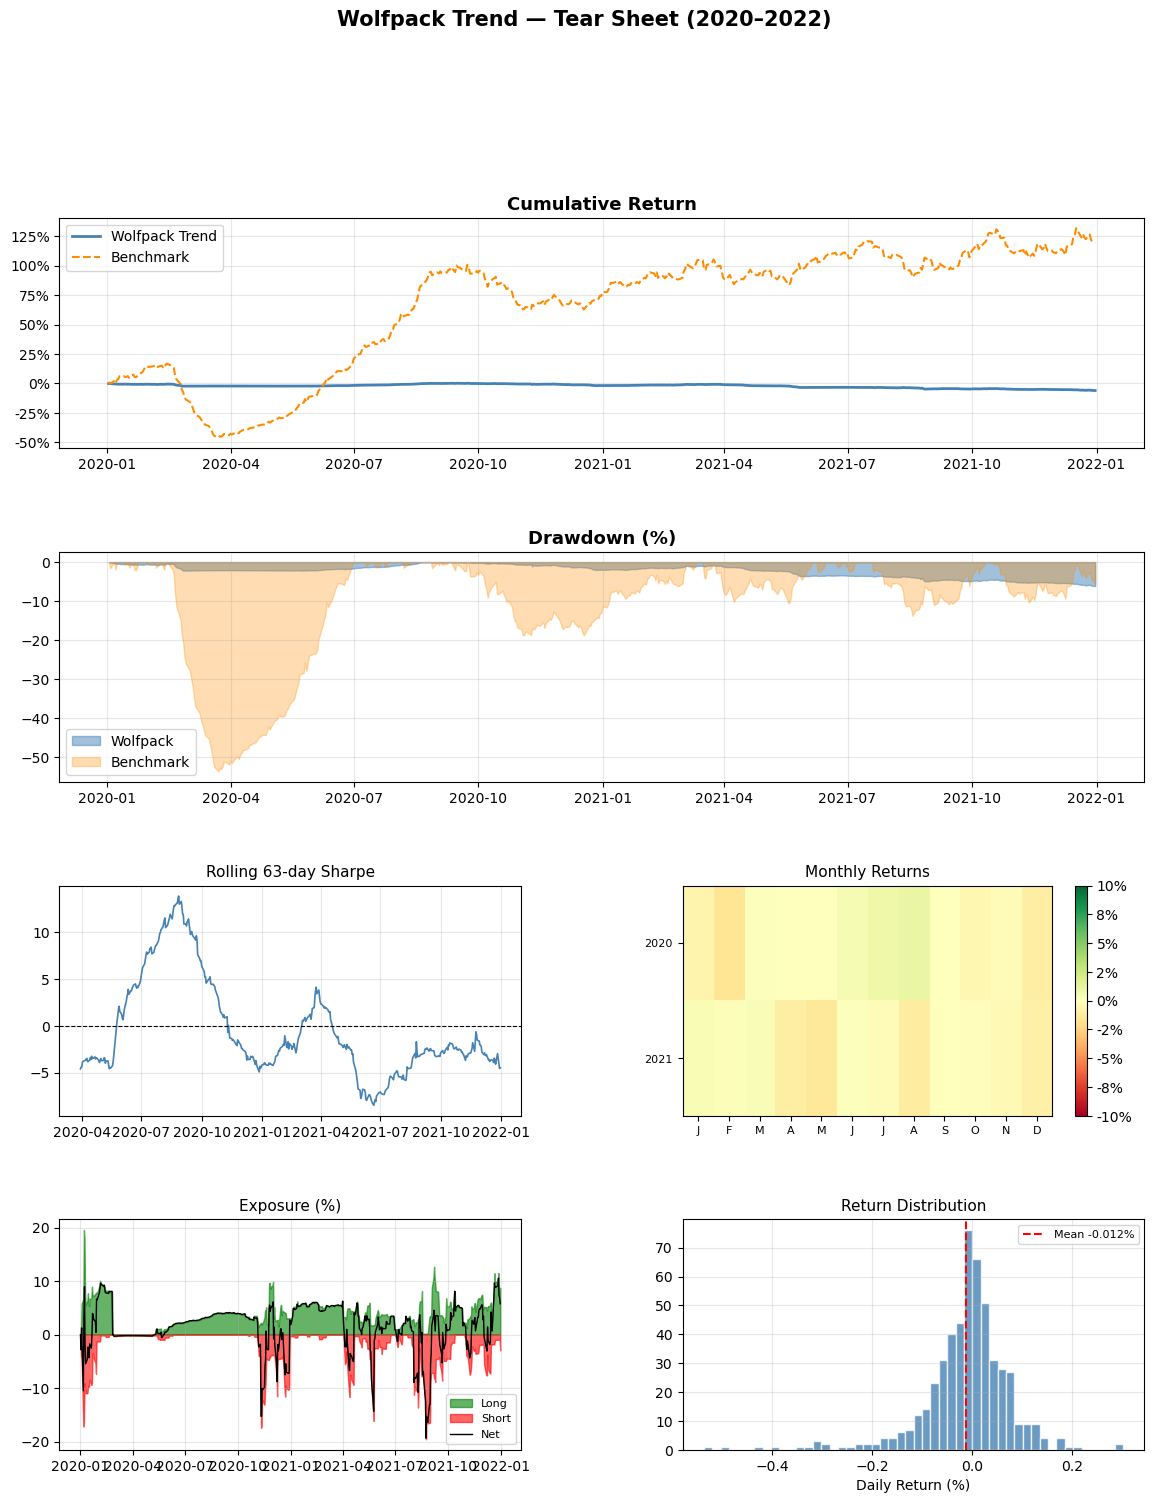

In [6]:
def dd_series(r):
    c = (1+r).cumprod(); return (c - c.cummax()) / c.cummax()

pct = FuncFormatter(lambda x, _: f'{x:.0%}')
fig = plt.figure(figsize=(14, 16))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

ax = fig.add_subplot(gs[0, :])
ax.plot((1+sr).cumprod()-1, label='Wolfpack Trend', color='steelblue', lw=2)
ax.plot((1+br).cumprod()-1, label='Benchmark', color='darkorange', lw=1.5, ls='--')
ax.yaxis.set_major_formatter(pct)
ax.set_title('Cumulative Return', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[1, :])
ax.fill_between(sr.index, dd_series(sr)*100, 0, alpha=0.5, color='steelblue', label='Wolfpack')
ax.fill_between(br.index, dd_series(br)*100, 0, alpha=0.3, color='darkorange', label='Benchmark')
ax.set_title('Drawdown (%)', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[2, 0])
roll_sh = sr.rolling(63).apply(lambda x: x.mean()/x.std()*np.sqrt(252) if x.std()>0 else np.nan, raw=True)
ax.plot(roll_sh, color='steelblue', lw=1.2)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Rolling 63-day Sharpe', fontsize=11); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[2, 1])
monthly = sr.resample('ME').apply(lambda x: (1+x).prod()-1)
heat = pd.DataFrame({'ret': monthly.values, 'year': monthly.index.year,
                     'month': monthly.index.month}).pivot(index='year', columns='month', values='ret')
im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn', vmin=-0.10, vmax=0.10)
ax.set_xticks(range(12))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=8)
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index, fontsize=8)
ax.set_title('Monthly Returns', fontsize=11)
plt.colorbar(im, ax=ax, format=FuncFormatter(lambda x,_: f'{x:.0%}'))

ax = fig.add_subplot(gs[3, 0])
ax.fill_between(snap.index, snap['long_exposure']*100, alpha=0.6, color='green', label='Long')
ax.fill_between(snap.index, -snap['short_exposure']*100, alpha=0.6, color='red', label='Short')
ax.plot(snap.index, snap['net_exposure']*100, color='black', lw=1, label='Net')
ax.set_title('Exposure (%)', fontsize=11); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[3, 1])
ax.hist(sr.values*100, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(sr.mean()*100, color='red', lw=1.5, ls='--', label=f'Mean {sr.mean()*100:.3f}%')
ax.set_xlabel('Daily Return (%)'); ax.set_title('Return Distribution', fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Wolfpack Trend — Tear Sheet (2020–2022)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/tearsheet.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print('=== Constraint Violations ===')
print(f'Gross > 150%  : {(snap["gross_exposure"] > 1.50).sum()} days')
print(f'|Net| > 50%   : {(snap["net_exposure"].abs() > 0.50).sum()} days')
print(f'Peak positions: {snap["num_positions"].max()}')

=== Constraint Violations ===
Gross > 150%  : 0 days
|Net| > 50%   : 0 days
Peak positions: 25
